In [2]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


import warnings
warnings.filterwarnings("ignore")


In [3]:
# Load Dataset

df = pd.read_csv(r"D:\Titanic-Dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,3,1,27.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
7,0,3,0,2.0,3,1,21.0750,2
8,1,3,0,27.0,0,2,11.1333,2
9,1,2,0,14.0,1,0,30.0708,0


In [5]:
df.tail(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,3,1,27.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
7,0,3,0,2.0,3,1,21.0750,2
8,1,3,0,27.0,0,2,11.1333,2
9,1,2,0,14.0,1,0,30.0708,0


In [6]:
print("Rows and Columns :", df.shape)

Rows and Columns : (10, 8)


In [7]:
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  10 non-null     int64  
 1   Pclass    10 non-null     int64  
 2   Sex       10 non-null     int64  
 3   Age       10 non-null     float64
 4   SibSp     10 non-null     int64  
 5   Parch     10 non-null     int64  
 6   Fare      10 non-null     float64
 7   Embarked  10 non-null     int64  
dtypes: float64(2), int64(6)
memory usage: 772.0 bytes


In [9]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.500000,2.300000,0.500000,28.000000,0.700000,0.300000,27.020820,1.500000
std,0.527046,0.948683,0.527046,14.094916,0.948683,0.674949,23.601938,0.849837
min,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,7.250000,0.000000
25%,0.000000,1.250000,0.000000,23.000000,0.000000,0.000000,8.152075,1.250000
50%,0.500000,3.000000,0.500000,27.000000,0.500000,0.000000,16.104150,2.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,46.414575,2.000000
max,1.000000,3.000000,1.000000,54.000000,3.000000,2.000000,71.283300,2.000000


In [10]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
5,0,3,1,27.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
8,1,3,0,27.0,0,2,11.1333,2
3,1,1,1,35.0,1,0,53.1000,2
1,1,1,0,38.0,1,0,71.2833,0


In [13]:
print("Number of Passengers :", len(df))
print("Number of Features :", len(df.columns))
print("Target Column :", "Survived")

Number of Passengers : 10
Number of Features : 8
Target Column : Survived


In [14]:
# Check missing values

df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [16]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [17]:
df.drop(columns=['Cabin'], inplace=True)

KeyError: "['Cabin'] not found in axis"

In [ ]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [ ]:
df.head()

In [ ]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
df['Embarked'] = le.fit_transform(df['Embarked'])

In [ ]:
df.dtypes

In [18]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [19]:
df.to_csv(r"D:\Titanic-Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [20]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,3,1,27.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
7,0,3,0,2.0,3,1,21.0750,2
8,1,3,0,27.0,0,2,11.1333,2
9,1,2,0,14.0,1,0,30.0708,0


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Increase default figure size
plt.rcParams["figure.figsize"] = (8,5)

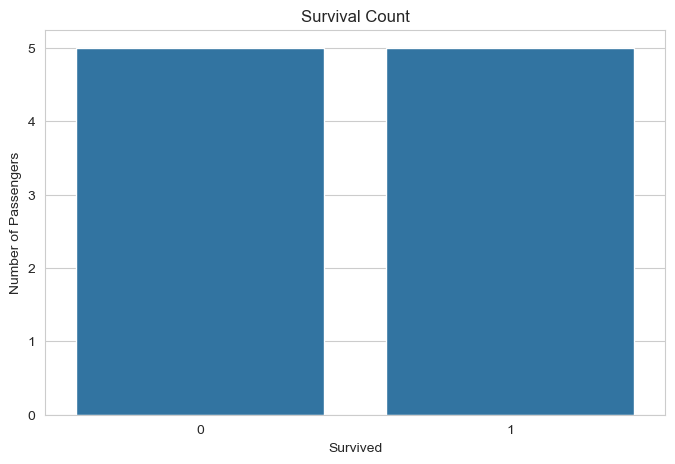

In [22]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

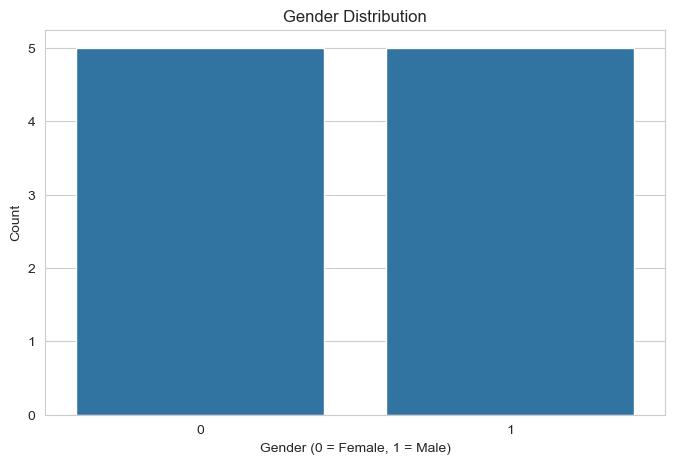

In [23]:
sns.countplot(x='Sex', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")

plt.show()

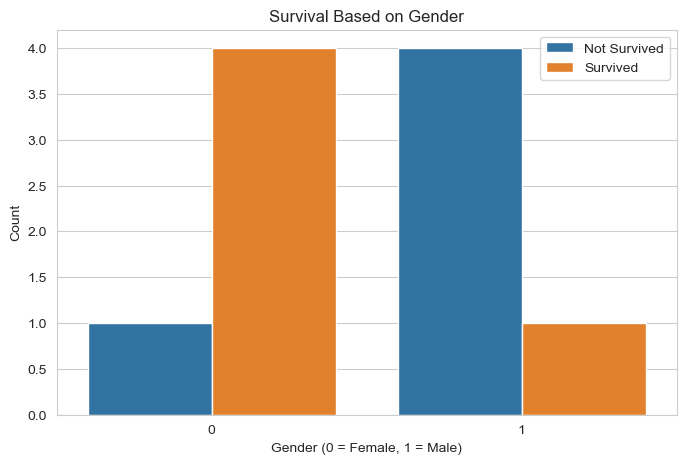

In [24]:
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Based on Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")

plt.legend(["Not Survived", "Survived"])

plt.show()

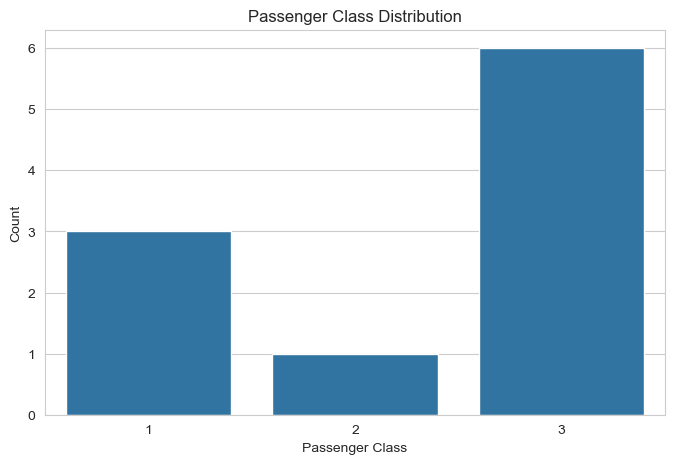

In [25]:
sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

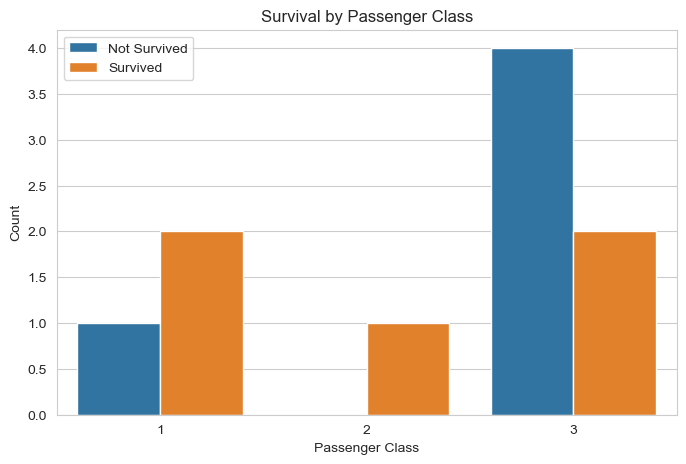

In [26]:
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.legend(["Not Survived", "Survived"])

plt.show()

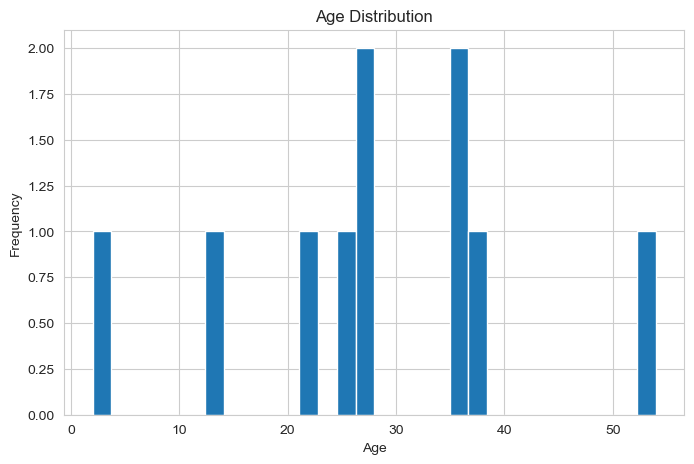

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

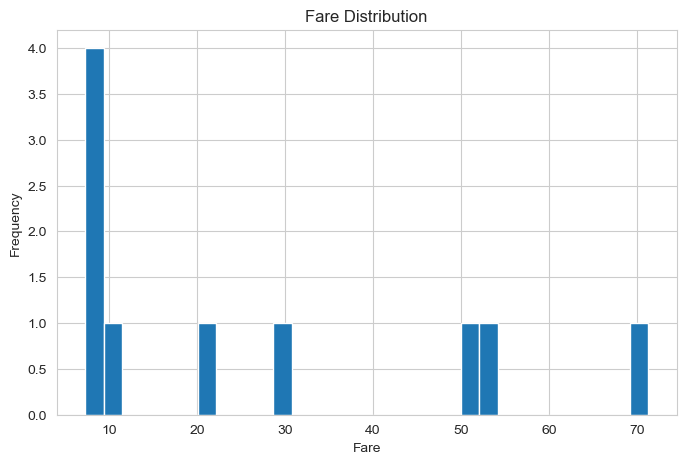

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df['Fare'], bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

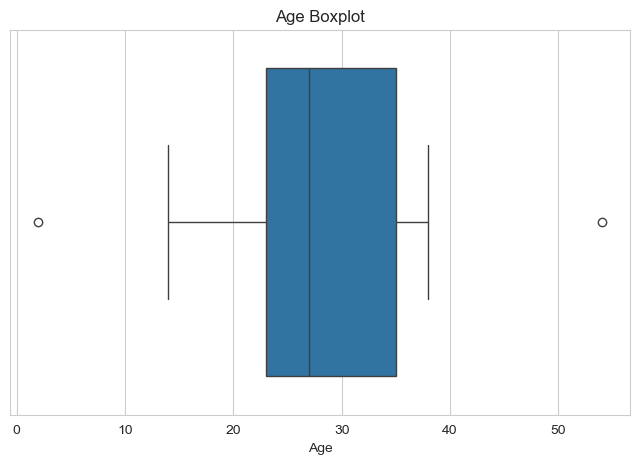

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age'])

plt.title("Age Boxplot")

plt.show()

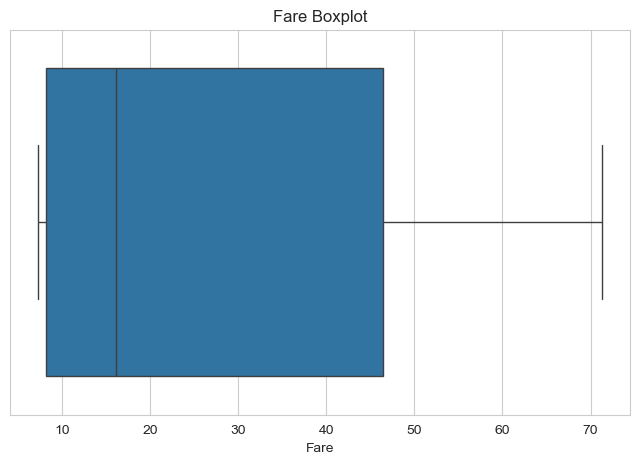

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Fare'])

plt.title("Fare Boxplot")

plt.show()

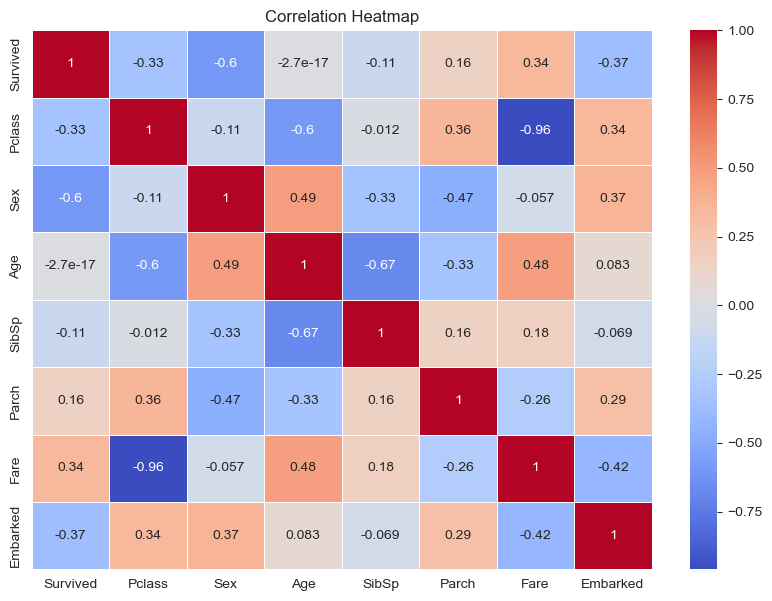

In [31]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

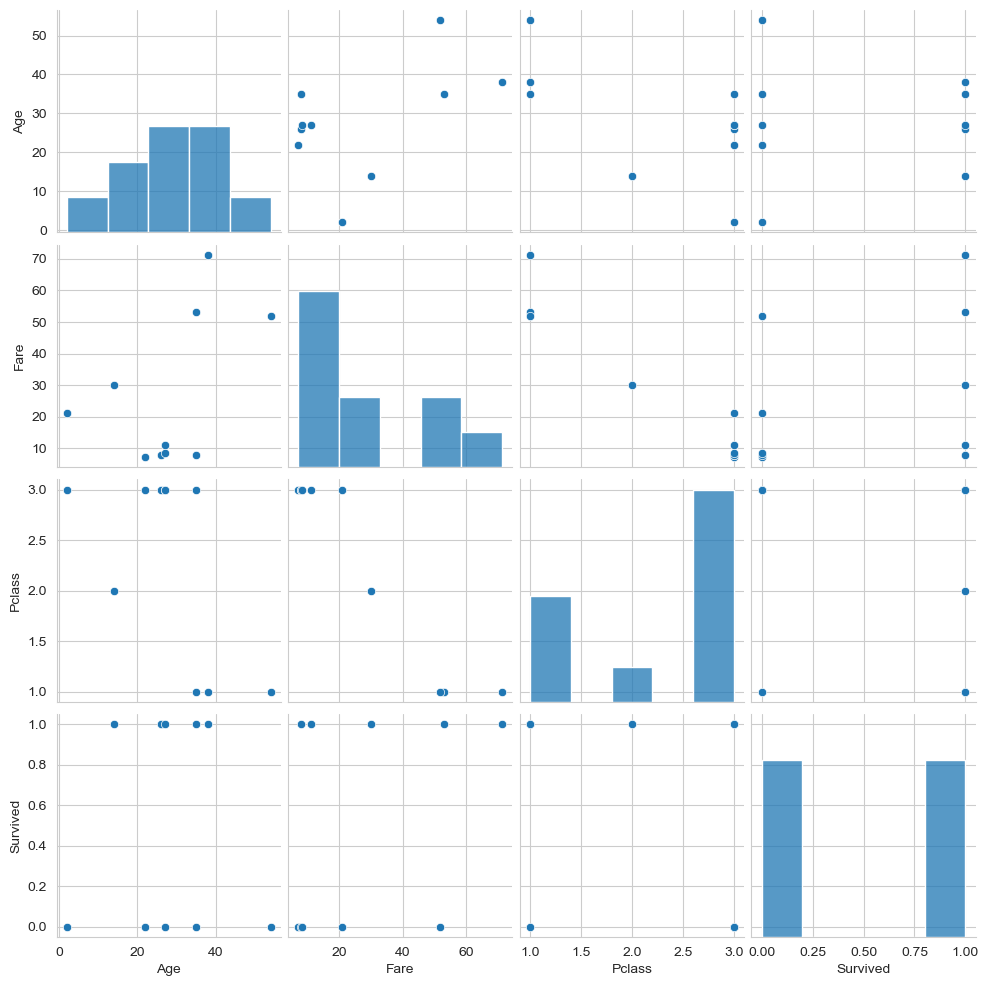

In [32]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']])

plt.show()

In [33]:
print("Data Visualization Completed Successfully!")

Data Visualization Completed Successfully!


In [34]:
# Features (Independent Variables)
X = df.drop('Survived', axis=1)

# Target (Dependent Variable)
y = df['Survived']

print("Features Selected Successfully!")

Features Selected Successfully!


In [35]:
print(X.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    1  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


In [36]:
print(y.head())

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [37]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (10, 7)
Target Shape : (10,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (8, 7)
Testing Features : (2, 7)
Training Target : (8,)
Testing Target : (2,)


In [40]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [41]:
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [42]:
print(model)

LogisticRegression(max_iter=1000, random_state=42)


In [43]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef

,Feature,Coefficient
0,Pclass,-0.041150
1,Sex,-0.745441
2,Age,0.080758
3,SibSp,-0.481657
4,Parch,0.437421
5,Fare,0.104557
6,Embarked,0.228915


In [44]:
print("Intercept :", model.intercept_[0])

Intercept : -3.6198984578466358


In [45]:
train_prediction = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_prediction)

print("Training Accuracy :", round(train_accuracy * 100,2), "%")

Training Accuracy : 87.5 %


In [46]:
print("Feature Selection and Model Training Completed Successfully!")

Feature Selection and Model Training Completed Successfully!


In [47]:
# Predict the test dataset
y_pred = model.predict(X_test)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [48]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,1
1,1,1


In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy = {:.2f}%".format(accuracy * 100))

Model Accuracy = 50.00%


In [50]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 1]
 [0 1]]


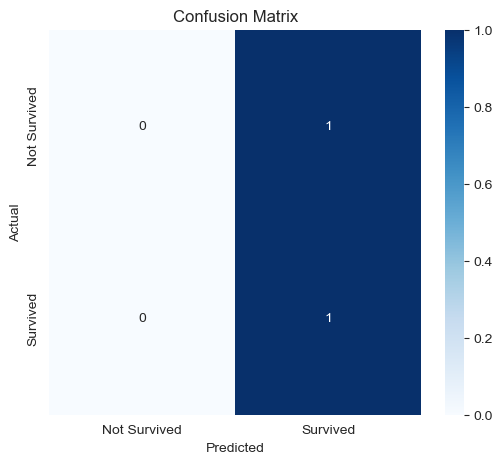

In [51]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [52]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



In [53]:
print("Accuracy  : Overall correctness of the model")
print("Precision : Correct positive predictions")
print("Recall    : Ability to identify actual survivors")
print("F1 Score  : Balance between Precision and Recall")

Accuracy  : Overall correctness of the model
Precision : Correct positive predictions
Recall    : Ability to identify actual survivors
F1 Score  : Balance between Precision and Recall


In [54]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
1,Sex,-0.745441
3,SibSp,-0.481657
4,Parch,0.437421
6,Embarked,0.228915
5,Fare,0.104557
2,Age,0.080758
0,Pclass,-0.041150


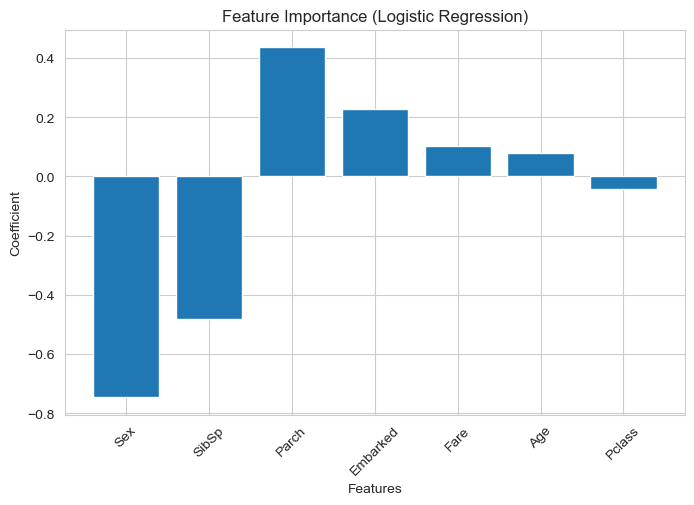

In [55]:
plt.figure(figsize=(8,5))

plt.bar(importance['Feature'], importance['Coefficient'])

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.xticks(rotation=45)

plt.show()

In [56]:
results = X_test.copy()

results['Actual'] = y_test.values
results['Predicted'] = y_pred

results.to_csv("Titanic_Predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [57]:
print("="*50)
print("MODEL EVALUATION COMPLETED")
print("="*50)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("\nProject Successfully Executed!")

MODEL EVALUATION COMPLETED
Accuracy : 50.00%

Project Successfully Executed!


In [58]:
# New passenger details
# Pclass = 3
# Sex = Male (1)
# Age = 22
# SibSp = 1
# Parch = 0
# Fare = 7.25
# Embarked = Southampton (2)

new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': [1],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': [2]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("✅ Passenger Survived")
else:
    print("❌ Passenger Did Not Survive")

❌ Passenger Did Not Survive


In [59]:
probability = model.predict_proba(new_passenger)

print("Probability of NOT Surviving : {:.2f}%".format(probability[0][0]*100))
print("Probability of Surviving     : {:.2f}%".format(probability[0][1]*100))

Probability of NOT Surviving : 87.85%
Probability of Surviving     : 12.15%


In [60]:
# Uncomment only if joblib is not installed

 !pip install joblib

IndentationError: unexpected indent (3815975385.py, line 3)

In [61]:
import joblib

joblib.dump(model, "Titanic_Model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [62]:
loaded_model = joblib.load("Titanic_Model.pkl")

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


In [63]:
prediction = loaded_model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Did Not Survive


In [64]:
test_passengers = pd.DataFrame({
    'Pclass': [1, 2, 3],
    'Sex': [0, 1, 0],
    'Age': [25, 40, 18],
    'SibSp': [0, 1, 0],
    'Parch': [0, 1, 0],
    'Fare': [100, 30, 8],
    'Embarked': [2, 0, 2]
})

predictions = loaded_model.predict(test_passengers)

results = test_passengers.copy()
results['Prediction'] = predictions

results['Prediction'] = results['Prediction'].map({
    0: 'Not Survived',
    1: 'Survived'
})

results

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Prediction
0,1,0,25,0,0,100,2,Survived
1,2,1,40,1,1,30,0,Survived
2,3,0,18,0,0,8,2,Not Survived


In [65]:
print("=" * 60)
print("        TITANIC SURVIVAL PREDICTION PROJECT")
print("=" * 60)

print("Algorithm Used      : Logistic Regression")
print("Dataset             : Titanic Dataset")
print("Target Variable     : Survived")
print("Total Features      :", X.shape[1])
print("Training Samples    :", X_train.shape[0])
print("Testing Samples     :", X_test.shape[0])
print("Model Accuracy      : {:.2f}%".format(accuracy * 100))

print("=" * 60)
print("Project Completed Successfully!")
print("=" * 60)

        TITANIC SURVIVAL PREDICTION PROJECT
Algorithm Used      : Logistic Regression
Dataset             : Titanic Dataset
Target Variable     : Survived
Total Features      : 7
Training Samples    : 8
Testing Samples     : 2
Model Accuracy      : 50.00%
Project Completed Successfully!


In [66]:
pip install streamlit scikit-learn pandas numpy joblib

Note: you may need to restart the kernel to use updated packages.


In [67]:
import joblib

joblib.dump(model, "Titanic_Model.pkl")

['Titanic_Model.pkl']

In [68]:
import streamlit as st
import pandas as pd
import joblib

# Load the trained model
model = joblib.load("Titanic_Model.pkl")

st.set_page_config(page_title="Titanic Survival Prediction", page_icon="🚢")

st.title("🚢 Titanic Survival Prediction")
st.write("Enter passenger details below to predict survival.")

# User Inputs
pclass = st.selectbox("Passenger Class", [1, 2, 3])
sex = st.selectbox("Sex", ["Female", "Male"])
age = st.slider("Age", 1, 80, 25)
sibsp = st.number_input("Siblings/Spouses Aboard", 0, 10, 0)
parch = st.number_input("Parents/Children Aboard", 0, 10, 0)
fare = st.number_input("Fare", 0.0, 600.0, 32.0)
embarked = st.selectbox("Embarked", ["C", "Q", "S"])

# Encoding
sex = 0 if sex == "Female" else 1
embarked = {"C": 0, "Q": 1, "S": 2}[embarked]

# Predict
if st.button("Predict"):
    sample = pd.DataFrame({
        "Pclass": [pclass],
        "Sex": [sex],
        "Age": [age],
        "SibSp": [sibsp],
        "Parch": [parch],
        "Fare": [fare],
        "Embarked": [embarked]
    })

    prediction = model.predict(sample)
    probability = model.predict_proba(sample)

    if prediction[0] == 1:
        st.success("✅ Passenger is likely to Survive")
    else:
        st.error("❌ Passenger is unlikely to Survive")

    st.write(f"**Survival Probability:** {probability[0][1] * 100:.2f}%")

2026-07-31 23:15:30.067 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 23:15:30.069 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 23:15:30.364 
  command:

    streamlit run C:\Users\ASUS\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-31 23:15:30.365 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 23:15:30.368 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 23:15:30.370 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 23:15:30.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runni